# 문화누리카드 가맹점 마스터 테이블 생성

목적: 데이터 전처리 및 필요 attribute 결정, 그리고 핵심 정보 EDA
- 문화누리카드 가맹점 원자료의 위치, 분류, 이용서비스 정보를 정제하여 도보 및 대중교통 접근성 분석에 활용 가능한 가맹점 단위 정보를 생성한다.
- 필요정보: 가맹점 ID, 분류, 위치정보, 기타 편의시설(장애인, 노인)과 시군구·행정동 구역 정보
* 접근성을 계산할 수 있는 정보들이 필수로 담겨야 함


In [22]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import pathlib
import numpy as np
import pathlib
from matplotlib.colors import LinearSegmentedColormap
import mapclassify as mc

salmon_cmap = LinearSegmentedColormap.from_list(
    "salmon_cmap",
    ["#fff5f0", "#fddbc7", "#f4a582", "#ef8a62", "#d6604d", "#b2182b"]
)

plt.rcParams["font.family"] = "Noto Sans KR"

BASE_PATH = pathlib.Path().resolve()
if BASE_PATH.name == 'notebooks':
    BASE_PATH = BASE_PATH.parent.parent

if BASE_PATH.name == 'analysis_table':
    BASE_PATH == BASE_PATH.parent

ANALYSIS_PATH = BASE_PATH / "analysis_table"
ANALYSIS_PATH.mkdir(parents = True, exist_ok = True)

DATA_PATH = ANALYSIS_PATH / "data"
DATA_PATH.mkdir(parents = True, exist_ok = True)

INPUT_PATH = DATA_PATH / "input"
INPUT_PATH.mkdir(parents = True, exist_ok=True)

OUTPUT_PATH = DATA_PATH / "output"
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

IMAGE_PATH = ANALYSIS_PATH / "image"
IMAGE_PATH.mkdir(parents=True, exist_ok=True)

RAW_PATH = BASE_PATH / "data" / "raw"

SPATIAL_PATH = RAW_PATH / "spatial"

## 데이터 불러오기 및 데이터 칼럼 정제

    # 첫 번째 행에 대분류·중분류·소분류·시군구 정보가 보조 헤더 형태 
    # 해당 행은 실제 가맹점 레코드가 아니므로 제거
    # 이후 가맹점명, 대분류, 중분류, 소분류, 위도, 경도, 시군구, 주소, 이용정보, 연관검색어, URL, 이용분류 관련 칼럼 선택
    #  `Unnamed` 칼럼과 줄바꿈이 포함된 칼럼명을 분석에 용이한 칼럼명으로 변환

In [23]:
store = pd.read_excel(RAW_PATH / "merchants" / "source" / "mnc_seoul_offline_merchants_20260706.xlsx")

# 데이터 품질 점검 및 필요 칼럼 정리
print(store.columns)
print(store.shape)
print(store.isna().sum())


display(store.loc[0, :])
display(store.head())
display(store["지역"].value_counts())

# 1행의 일부 정보가 보조 헤더 역할
# 분야: 대분류, 지역: 시 , 'Unnamed: 4': 중분류, 'Unnamed: 5: 소분류, Unnamed: 12: 시군구

# 1행 제거
store = store.iloc[1:].copy()
store = store.reset_index(drop=True)

# 필요 칼럼 선택
store = store[['가맹점명', '분야', 'Unnamed: 4', 'Unnamed: 5', '위도', '경도',
       '이용정보', 'Unnamed: 12', '주소',
       '연관검색어', 'URL',  '이용분류', '이용분류\n전화결제','이용분류\n상세내용']].copy()


# 칼럼명 정리
store.rename(columns = {"분야": '대분류', 
                        'Unnamed: 4': '중분류', 
                        'Unnamed: 5': '소분류', 
                        'Unnamed: 12': '시군구',
                        '이용분류\n전화결제': '이용분류_전화결제',
                        '이용분류\n상세내용': '이용분류_상세내용'},
             inplace = True,
             errors = 'ignore')

print(f"칼럼 선택 결과 확인: {store.columns}")
    # 칼럼 선택 결과 확인: Index(['가맹점명', '대분류', '중분류', '소분류', '위도', '경도', '이용정보', '시군구', '주소', '연관검색어',
    #        'URL', '이용분류', '이용분류_전화결제', '이용분류_상세내용'],
    #       dtype='str')


Index(['번호', '가맹점명', '가맹점구분', '분야', 'Unnamed: 4', 'Unnamed: 5', '위도', '경도',
       '이용정보', '할인정보\n여부', '할인정보\n상세내역', '지역', 'Unnamed: 12', '주소',
       '마지막\n수정일자', '최초 등록일', '연관검색어', 'URL', '등록주체\n구분', '이용분류', '이용분류\n전화결제',
       '이용분류\n상세내용'],
      dtype='str')
(4728, 22)
번호             4728
가맹점명              1
가맹점구분             1
분야                0
Unnamed: 4        0
Unnamed: 5        0
위도                1
경도                1
이용정보           1583
할인정보\n여부          1
할인정보\n상세내역     4275
지역                0
Unnamed: 12       0
주소                1
마지막\n수정일자       374
최초 등록일            1
연관검색어             1
URL            3773
등록주체\n구분       1282
이용분류           4283
이용분류\n전화결제     4487
이용분류\n상세내용     4460
dtype: int64


번호             NaN
가맹점명           NaN
가맹점구분          NaN
분야             대분류
Unnamed: 4     중분류
Unnamed: 5     소분류
위도             NaN
경도             NaN
이용정보           NaN
할인정보\n여부       NaN
할인정보\n상세내역     NaN
지역              광역
Unnamed: 12     기초
주소             NaN
마지막\n수정일자      NaT
최초 등록일         NaT
연관검색어          NaN
URL            NaN
등록주체\n구분       NaN
이용분류           NaN
이용분류\n전화결제     NaN
이용분류\n상세내용     NaN
Name: 0, dtype: object

,번호,가맹점명,가맹점구분,분야,Unnamed: 4,Unnamed: 5,위도,경도,이용정보,할인정보\n여부,...,Unnamed: 12,주소,마지막\n수정일자,최초 등록일,연관검색어,URL,등록주체\n구분,이용분류,이용분류\n전화결제,이용분류\n상세내용
0,NaN,NaN,NaN,대분류,중분류,소분류,NaN,NaN,NaN,NaN,...,기초,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,피트니스써밋,오프라인,체육,체육시설,체육시설,37.585338,126.914969,헬스 이용권 3개월 260000/6개월360000/12개월 420000\n운영시간 ...,NO,...,서대문구,서울특별시 서대문구 응암로 145 3층,2026-07-03 22:00:01,2026-06-30 17:01:40,#헬스#pt,NaN,가맹점주(온라인),NaN,NaN,NaN
2,NaN,상지악기,오프라인,문화,음악,음악,37.535248,127.132664,"매장 방문 시에 야마하, 삼익, 영창 등 다양한 악기 브랜드의 악기를 문화누리카드로...",NO,...,강동구,서울특별시 강동구 천호대로 1092 에스케이 허브진 1층 114-1호 (주)상지악기,2026-07-01 22:00:02,2026-06-30 16:48:48,#상지악기#야마하#디지털피아노#악기#악기점#피아노#플룻#바이올린#기타#드럼#삼익#영창,https://smartstore.naver.com/duzonpiano,가맹점주(온라인),NaN,NaN,NaN
3,NaN,스파이럴치어리딩학원(스파이럴 치어리딩학원),오프라인,체육,체육시설,체육시설,37.541578,127.094914,"치어리딩학원\n등록 전 1회 체험비 : 3~4만원\n등록 시 주 1회 17만원, 주...",NO,...,광진구,서울특별시 광진구 광나루로 604 6층,2026-07-03 22:00:01,2026-06-30 11:31:22,#치어리딩 #체육 #운동 #발레 #체조 #기계체조 #리듬체조,http://spiraldance.kr,가맹점주(온라인),NaN,NaN,NaN
4,NaN,잠실 한강공원 물놀이장(주식회사 중앙출판사),오프라인,체육,체육시설,체육시설,37.517629,127.086737,"6.19.(금)~8.30.(일) 무휴 운영\n입장권 : 어린이 1,000 / 청소년...",NO,...,송파구,서울특별시 송파구 한가람로 65 잠실 한강공원 물놀이장,2026-07-02 09:18:25,2026-06-29 12:57:08,#체육시설#한강수영장,NaN,가맹점주(주관처접수),NaN,NaN,NaN


지역
서울     4727
광역        1
Name: count, dtype: int64

칼럼 선택 결과 확인: Index(['가맹점명', '대분류', '중분류', '소분류', '위도', '경도', '이용정보', '시군구', '주소', '연관검색어',
       'URL', '이용분류', '이용분류_전화결제', '이용분류_상세내용'],
      dtype='str')


## 데이터 전처리
    # 결측치 처리
        # 가맹점 데이터의 결측 현황과 서비스 관련 칼럼의 내용을 확인함. 
        # 위치와 분류 관련 핵심 칼럼은 결측이 없어 접근성 분석에 활용 가능함을 확인했으며, 
        # 이용분류 칼럼은 전화결제, 찾아가는 문화서비스, 장애인친화시설 여부를 구분하는 이진 변수 생성에 활용하기로 함. 
        # 반면 이용분류_전화결제는 대부분 결측이고 전화번호 자체가 접근성 분석의 핵심 변수가 아니므로 제외함.
        #  이용정보와 이용분류_상세내용은 향후 키워드 분석 또는 외부 데이터 보완을 통해 부가적인 서비스 특성 변수로 활용할 수 있음.

    # 중복값 처리
        # 중복처리 기준: 가맹점명-중분류-소분류 기준 중복 (동일한 문화서비스를 제공하는 동일한 이름의 시설)
        # 미터계 좌표 기준 5m 이내는 동일한 시설이라고 판단
        # 정밀한 비교 위해 미터계 좌표(EPSG:5179)로 변환
        # 가맹점명-중분류-소분류 중복 레코드에 대해 geometry 거리 계산 후 5m 미만의 시설을 중복 시설이라고 정의
        # 총 5개의 중복행 제거

    # 중복 레코드
        #       가맹점명	중분류	소분류	거리m	idx_1	idx_2
        # 1	    극단친구	공연	공연	0.000000	3709	3714
        # 8	    면목제4동 주민센터	문화체험	문화체험	0	1647	1711
        # 12	미래서적	도서	도서	0.000000	307	540
        # 13	베토벤	    음악	음악	0.052191	2605	4383
        # 15	샐몬모텔	숙박	숙박	0.100241	195	4322




In [24]:
# 결측치 확인
    #     가맹점명	중분류	소분류	거리m	idx_1	idx_2
    # 1	극단친구	공연	공연	0.000000	3709	3714
    # 8	면목제4동 주민센터	문화체험	문화체험	0.000000	1647	1711
    # 12	미래서적	도서	도서	0.000000	307	540
    # 13	베토벤	음악	음악	0.052191	2605	4383
    # 15	샐몬모텔	숙박	숙박	0.100241	195	4322
        # 가맹점 데이터의 결측 현황과 서비스 관련 칼럼의 내용을 확인함. 
        # 위치와 분류 관련 핵심 칼럼은 결측이 없어 접근성 분석에 활용 가능함을 확인했으며, 
        # 이용분류 칼럼은 전화결제, 찾아가는 문화서비스, 장애인친화시설 여부를 구분하는 이진 변수 생성에 활용하기로 함. 
        # 반면 이용분류_전화결제는 대부분 결측이고 전화번호 자체가 접근성 분석의 핵심 변수가 아니므로 제외함.
        #  이용정보와 이용분류_상세내용은 향후 키워드 분석 또는 외부 데이터 보완을 통해 부가적인 서비스 특성 변수로 활용할 수 있음.
    # 가맹점명            0
    # 대분류             0
    # 중분류             0
    # 소분류             0
    # 위도              0
    # 경도              0
    # 이용정보         1582
    # 시군구             0
    # 주소              0
    # 연관검색어           0
    # URL          3772
    # 이용분류         4282
    # 이용분류_전화결제    4486
    # 이용분류_상세내용    4459
    # dtype: int64

print(store.shape)
print(store.isna().sum())
print(store["이용분류"].unique()) # 전화결제, 장애인친화시설, 찾아가는 문화서비스 등 서비스 여부 - 포함항목 별로 나눠서 새로운 칼럼 유형 생성, 추가 웹크롤링으로 데이터 보완 가능
print(store["이용분류_전화결제"].unique()) # 전화번호 - 필요없음
print(store["이용정보"].unique()) # 시설에 관한 정보 - 키워드 분석으로 사용할 수는 있을듯? 결측치는 네이버 크롤링으로 커버 가능할수도
print(store["이용분류_상세내용"].unique()) # 전화결제, 장애인친화시설, 찾아가는 문화서비스 등 서비스 여부에 관한 상세 설명 - 키워드 분석으로 사용할 수 있을듯? 어떻게 사용할지는 아직 미정

(4727, 14)
가맹점명            0
대분류             0
중분류             0
소분류             0
위도              0
경도              0
이용정보         1582
시군구             0
주소              0
연관검색어           0
URL          3772
이용분류         4282
이용분류_전화결제    4486
이용분류_상세내용    4459
dtype: int64
<StringArray>
[                      nan, '전화결제,찾아가는 문화서비스,장애인친화시설',
                 '장애인친화시설',              '찾아가는 문화서비스',
                    '전화결제',      '찾아가는 문화서비스,장애인친화시설',
         '전화결제,찾아가는 문화서비스',            '전화결제,장애인친화시설']
Length: 8, dtype: str
<StringArray>
[            nan,   '02-741-8881',  '02-3672-6000', '010-2627-5488',
   '02-426-0306',   '02-736-7047', '010-6407-2784', '010-9293-0773',
   '02-996-2288',   '02-318-3005',
 ...
   '02-749-4242',   '02-730-3205', '010-5797-1705',   '02-743-1105',
 '010-2908-2929',     '6789-4334',   '02-478-0221',  '02-3011-9200',
 '010-2291-4587',   '02-724-6875']
Length: 234, dtype: str
<StringArray>
[                                                                

In [25]:
# 이용분류_전화결제 칼럼 삭제
store = store.drop(columns = "이용분류_전화결제",
                   errors = 'ignore')


# 이용분류 - 서비스 별 칼럼 생성
store['전화결제'] = store["이용분류"].astype(str).str.contains('전화결제').astype(int)
store['장애인친화시설'] = store["이용분류"].astype(str).str.contains('장애인친화시설').astype(int)
store['찾아가는문화서비스'] = store["이용분류"].astype(str).str.contains('찾아가는문화서비스').astype(int)
store = store.drop(columns = '이용분류',
                   errors = 'ignore')

# 칼럼 정리
store = store [['가맹점명', '시군구', '주소', '위도', '경도', '대분류', '중분류', '소분류', '전화결제', '장애인친화시설', '찾아가는문화서비스', '이용정보', '연관검색어',
       '이용분류_상세내용', 'URL']]

In [26]:
# 위도 0.00001도 ≈ 약 1.1m
# 경도 0.00001도 ≈ 서울 기준 약 0.9m
# 서울시 좌표는 4326보다 5179로 좌표변환후 좌표 확인하는 것이 더 중요.

# 서울시 기준 데카르트 좌표계로 변환
store = store.copy()
store = gpd.GeoDataFrame(store,
                         geometry = gpd.points_from_xy(store["경도"], store["위도"]),
                         crs = "EPSG: 4326")
store = store.to_crs("EPSG: 5179")


# 중복 제거 기준 : 가맹점 명 - 중분류, 소분류 동일, geometry 거리가 몇 미터 이내
    # 가맹점명_중분류_소분류 중복 후보 행 개수: 87
store_dup = store[["가맹점명", "중분류", "소분류"]].duplicated(keep=False)

dup_store = store[store_dup].copy()
print(f"가맹점명_중분류_소분류 중복 후보 행 개수: {len(dup_store)}")
display(dup_store.sort_values(["가맹점명", "중분류", "소분류"]))

# 같은 가맹점명 + 중분류 + 소분류 조합 geometry 비교
dup_dist_list = []
for key, group in dup_store.groupby(["가맹점명", "중분류", "소분류"]): # key는 그룹 키값, group은 그 키에 해당하는 행들
    group = group.copy()
    for i in range(len(group)):
        for j in range(i+1, len(group)):
            idx_i = group.index[i]
            idx_j = group.index[j]
            
            dist_m = group.loc[idx_i, "geometry"].distance(group.loc[idx_j, "geometry"])
            
            dup_dist_list.append({"가맹점명": key[0],
                                  "중분류": key[1],
                                  "소분류": key[2],
                                  "거리m": dist_m,
                                  "idx_1": idx_i,
                                  "idx_2": idx_j})

dup_store_table = pd.DataFrame(dup_dist_list)
display(dup_store_table.sort_values("거리m", ascending=True))

dup_idx = dup_store_table.loc[(dup_store_table["거리m"] < 5), "idx_2"].unique()
print(dup_idx)

# 기준 중복 행 제거
store_clean= store.drop(index = dup_idx)
print(f"중복 행 제거 개수: {len(store) - len(store_clean)}")


가맹점명_중분류_소분류 중복 후보 행 개수: 87


,가맹점명,시군구,주소,위도,경도,대분류,중분류,소분류,전화결제,장애인친화시설,찾아가는문화서비스,이용정보,연관검색어,이용분류_상세내용,URL,geometry
2533,21세기문고,강북구,서울 강북구 도봉로 189,37.625632,127.026117,문화,도서,도서,0,0,0,NaN,#문화#도서#서점#서적#책#책방#21세기문고#이십일세기문고,NaN,NaN,POINT (958183.562 1958570)
3795,21세기문고,강남구,서울 강남구 남부순환로359길 31 (도곡동),37.486796,127.035553,문화,도서,도서,0,0,0,NaN,#문화#도서#서점#서적#문고#책방#21세기문고,NaN,NaN,POINT (958940.15 1943162.717)
3709,극단친구,노원구,서울특별시 노원구 한글비석로46나길 2-4,37.666935,127.069594,문화,공연,공연,0,0,0,NaN,#문화#공연#공연장#에듀테인먼트놀#극단친구,NaN,NaN,POINT (962041.154 1963133.884)
3714,극단친구,노원구,서울특별시 노원구 한글비석로46나길 2-4,37.666935,127.069594,문화,공연,공연,0,0,0,NaN,#문화#공연#극단#공연단체#극단친구#친구,NaN,NaN,POINT (962041.154 1963133.884)
3787,글벗서점,강남구,서울특별시 강남구 도곡로 516 삼성상가 지하 1층,37.499191,127.063009,문화,도서,도서,0,0,0,도서,#문화#도서#서점#서적#문고#책방#글벗서점,NaN,NaN,POINT (961373.854 1944526.25)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3903,한양스튜디오,서대문구,서울 서대문구 홍은동 9-178,37.598489,126.949146,문화,미술,사진관,0,0,0,NaN,#문화#미술#사진관#스튜디오#사진#한양스튜디오,NaN,NaN,POINT (951373.804 1955595.63)
1090,현스튜디오,강서구,서울특별시 강서구 양천로14길 24 1층 현스튜디오,37.572062,126.809951,문화,미술,사진관,1,1,0,사진관(증명사진 등 다양한 사진 촬영 가능)\n,#사진#사진관,1층으로 장애인 출입이 원활합니다,NaN,POINT (939064.782 1952744.904)
3989,현스튜디오,서대문구,서울 서대문구 북가좌동 309-1,37.580764,126.911691,문화,미술,사진관,0,0,0,NaN,#문화#미술#사진관#스튜디오#사진#현스튜디오,NaN,NaN,POINT (948055.147 1953649.202)
518,현포토,강남구,서울특별시 강남구 언주로 117 우성아파트상가 상가동 지하1층,37.486466,127.050396,문화,미술,사진관,0,0,0,"사진촬영,액자제작,프로필촬영",#도곡동사진관#도곡동사진교육#도곡동플로필사진#도곡동증명사진#여권사진,NaN,NaN,POINT (960252.2 1943119.757)


,가맹점명,중분류,소분류,거리m,idx_1,idx_2
1,극단친구,공연,공연,0.000000,3709,3714
8,면목제4동 주민센터,문화체험,문화체험,0.000000,1647,1711
12,미래서적,도서,도서,0.000000,307,540
13,베토벤,음악,음악,0.052191,2605,4383
15,샐몬모텔,숙박,숙박,0.100241,195,4322
16,성무태권도장,체육시설,체육시설,614.771409,222,274
32,원 당구클럽,체육시설,체육시설,649.798373,3460,3475
17,성무태권도장,체육시설,체육시설,684.139853,222,622
19,성무태권도장,체육시설,체육시설,934.307540,274,622
20,성무태권도장,체육시설,체육시설,2377.159096,274,2508


[3714 1711  540 4383 4322]
중복 행 제거 개수: 5


## Point In Polygon 분석 기반 가맹점 위치 POI 유효성 검증
    # EPSG:4326으로 변환 후 분석 진행
    # PIP 분석 결과 총 20개의 가맹점이 서울 경계 바깥으로 확인
    # 해당 레코드 삭제 처리
    # 최종 가맹점 개수 : 4702개

crs 확인: EPSG:5186
지오타입 확인: <StringArray>
['Polygon']
Length: 1, dtype: str
데이터 구조 확인: (426, 4)


,BASE_DATE,ADM_CD,ADM_NM,geometry
0,20250630,11010530,사직동,"POLYGON ((197702.069 553187.311, 197703.431 55..."
1,20250630,11010540,삼청동,"POLYGON ((197980.839 555346.068, 197995.421 55..."
2,20250630,11010550,부암동,"POLYGON ((196621.023 556395.88, 196628.324 556..."
3,20250630,11010560,평창동,"POLYGON ((197800.72 559064.245, 197782.581 558..."
4,20250630,11010570,무악동,"POLYGON ((196444.745 553384.564, 196471.618 55..."


crs 확인: EPSG:5186
지오타입 확인: <StringArray>
['Polygon']
Length: 1, dtype: str
데이터 구조 확인: (426, 4)
결합 후 구조: (426, 4)
결합 후 결측:
ADM_CD      0
시군구         0
행정동         0
geometry    0
dtype: int64
결합 후 타입: <class 'geopandas.geodataframe.GeoDataFrame'>


,ADM_CD,시군구,행정동,geometry
0,11010530,종로구,사직동,"POLYGON ((197702.069 553187.311, 197703.431 55..."
1,11010540,종로구,삼청동,"POLYGON ((197980.839 555346.068, 197995.421 55..."
2,11010550,종로구,부암동,"POLYGON ((196621.023 556395.88, 196628.324 556..."
3,11010560,종로구,평창동,"POLYGON ((197800.72 559064.245, 197782.581 558..."
4,11010570,종로구,무악동,"POLYGON ((196444.745 553384.564, 196471.618 55..."


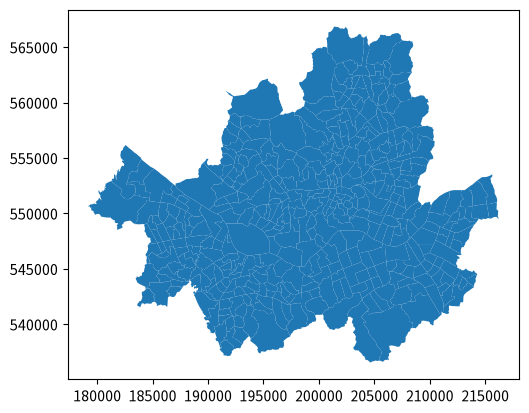

In [27]:
# 서울시 행정동 경계 불러오기
bound_kr = gpd.read_file(SPATIAL_PATH / "boundary" / "BND_ADM_DONG_PG.shp")

bound = bound_kr[bound_kr["ADM_CD"].astype(str).str.startswith("11")]

print(f"crs 확인: {bound.crs}")
print(f"지오타입 확인: {bound.geometry.geom_type.unique()}")
print(f"데이터 구조 확인: {bound.shape}")
bound.plot()
display(bound.head())

# 서울시 행정동 경계 칼럼 정리
bound = bound.copy()
bound = bound[["ADM_NM", "geometry"]]
bound = bound.rename(columns = {"ADM_NM": "행정동"})


# 시군구 행정동 데이터 불러오기
hjd_code = pd.read_excel(
    SPATIAL_PATH / "boundary" / "BND_ADM_DONG_PG_geocode.xlsx",
    sheet_name=0,
    header=1
)

# 시군구 행정동 데이터 칼럼 정리
# 서울시 행정동 경계 불러오기
bound_kr = gpd.read_file(
    SPATIAL_PATH / "boundary" / "BND_ADM_DONG_PG.shp",
    encoding="cp949"
)

bound_kr["ADM_CD"] = bound_kr["ADM_CD"].astype(str)

# 서울시 행정동만 선택
bound = bound_kr[bound_kr["ADM_CD"].str.startswith("11")].copy()

print(f"crs 확인: {bound.crs}")
print(f"지오타입 확인: {bound.geometry.geom_type.unique()}")
print(f"데이터 구조 확인: {bound.shape}")

# 시군구 행정동 코드표 불러오기
hjd_code = pd.read_excel(
    SPATIAL_PATH / "boundary" / "BND_ADM_DONG_PG_geocode.xlsx",
    sheet_name=0,
    header=1
)

# 코드 컬럼 정리
hjd_code = hjd_code[["시도코드", "시군구코드", "시군구명칭", "읍면동코드", "읍면동명칭"]].copy()

hjd_code["시도코드"] = hjd_code["시도코드"].astype(str).str.zfill(2)
hjd_code["시군구코드"] = hjd_code["시군구코드"].astype(str).str.zfill(3)
hjd_code["읍면동코드"] = hjd_code["읍면동코드"].astype(str).str.zfill(3)

hjd_code["ADM_CD"] = (
    hjd_code["시도코드"]
    + hjd_code["시군구코드"]
    + hjd_code["읍면동코드"]
)

# 서울시 코드만 선택
hjd_code = hjd_code[hjd_code["시도코드"] == "11"].copy()

hjd_code = hjd_code[["ADM_CD", "시군구명칭", "읍면동명칭"]].rename(
    columns={
        "시군구명칭": "시군구",
        "읍면동명칭": "행정동"
    }
)

# 경계 + 시군구/행정동명 결합
bound = bound.merge(
    hjd_code,
    on="ADM_CD",
    how="left"
)

bound = bound[["ADM_CD", "시군구", "행정동", "geometry"]].copy()

print(f"결합 후 구조: {bound.shape}")
print(f"결합 후 결측:\n{bound.isna().sum()}")
print(f"결합 후 타입: {type(bound)}")

display(bound.head())

# 테이블 저장
bound.to_file(OUTPUT_PATH / "서울시_시군구_행정동_경계.gpkg",
              driver = "GPKG")

,geometry,ADM_CD,시군구,행정동
0,"POLYGON ((190565.804 539271.534, 190555.038 53...",11010530,종로구,사직동


EPSG:5186
변경 crs: EPSG: 5179

서울 경계 바깥 가맹점


,가맹점명,시군구,주소,위도,경도,대분류,중분류,소분류,전화결제,장애인친화시설,찾아가는문화서비스,이용정보,연관검색어,이용분류_상세내용,URL,geometry,index_right
1229,엠에이치(MH) 토탈 휘트니스,양천구,서울특별시 양천구 신월로 164 10층,0.000000,0.000000,체육,체육시설,체육시설,1,0,0,"헬스,GX,스피닝,PT",#체육#체육시설#헬스#스피닝#GX#PT,NaN,https://mhtf.modoo.at,POINT (-5899757.108 17790114.866),NaN
1230,MH프리미엄PT헬스(엠에이치(MH)프리미엄),양천구,서울특별시 양천구 남부순환로 399 진성빌딩 2층,0.000000,0.000000,체육,체육시설,체육시설,0,0,0,헬스 / PT,#체육시설#헬스장#PT,NaN,https://mhpt1.modoo.at,POINT (-5899757.108 17790114.866),NaN
1231,상계2동 자치회관(상계2동 주민자치회),노원구,서울특별시 노원구 상계로 118 상계2동 주민센터,0.000000,0.000000,문화,문화체험,문화체험,0,0,0,"자치회관 프로그램 강좌(장구, 하모니카, 난타, 스포츠댄스, 드럼, 헬스, 스포츠댄...",#상계2동자치회관#문화,NaN,NaN,POINT (-5899757.108 17790114.866),NaN
1232,우리체육사,중구,서울특별시 중구 퇴계로 343-4 1층 우리체육사,0.000000,0.000000,체육,체육용품,체육용품,0,0,0,"체육사및체육용품판매\n헬스,구기,요가,필라테스용품(ex 아령,스트레칭밴드,폼롤러,공...",#체육#체육시설#학교#축구#농구#탁구#헬스#요가#필라테스#밴드#스트레칭,NaN,https://smartstore.naver.com/woorispom/best?cp=1,POINT (-5899757.108 17790114.866),NaN
1233,와룡스포츠센터(종로구시설관리공단),종로구,서울특별시 종로구 명륜길 28 4층 와룡스포츠센터,0.000000,0.000000,체육,체육시설,체육시설,0,0,0,"주요 프로그램 : 헬스, 스포츠",#체육#체육시설,NaN,https://www.ijongno.co.kr,POINT (-5899757.108 17790114.866),NaN
1234,동부여성문화센터(종로구시설관리공단),종로구,서울특별시 종로구 창신길 124 동부여성문화센터,0.000000,0.000000,체육,체육시설,체육시설,0,0,0,"주요 프로그램 : 헬스, 스포츠",#체육#체육시설,NaN,https://www.ijongno.co.kr,POINT (-5899757.108 17790114.866),NaN
1235,삼청테니스장(종로구시설관리공단),종로구,서울특별시 종로구 삼청로 156 삼청테니스장,0.000000,0.000000,체육,체육시설,체육시설,0,0,0,테니스,#체육#체육시설,NaN,https://www.ijongno.co.kr,POINT (-5899757.108 17790114.866),NaN
1236,종로구민회관(종로구시설관리공단),종로구,서울특별시 종로구 지봉로5길 7-5 종로구민회관,0.000000,0.000000,체육,체육시설,체육시설,0,0,0,"주요 프로그램 : 수영, 헬스, 문화, 스포츠",#체육#체육시설,NaN,https://www.ijongno.co.kr/,POINT (-5899757.108 17790114.866),NaN
1237,올림픽기념국민생활관(종로구시설관리공단),종로구,서울특별시 종로구 성균관로 91 국민생활관 올림픽기념국민생활관,0.000000,0.000000,체육,체육시설,체육시설,0,0,0,"주요 프로그램 : 수영, 헬스, 문화, 스포츠",#체육#체육시설,NaN,https://www.ijongno.co.kr/,POINT (-5899757.108 17790114.866),NaN
1238,종로문화체육센터(종로구시설관리공단),종로구,서울특별시 종로구 인왕산로1길 21 종로뮨화체육센터,0.000000,0.000000,체육,체육시설,체육시설,0,0,0,"주요 프로그램 : 수영, 헬스, 문화, 스포츠",#종로문화체육센터#종로#수영#체육시설,NaN,https://www.ijongno.co.kr/fmcs/3,POINT (-5899757.108 17790114.866),NaN


경게 바깥 가맹점 개수: 20


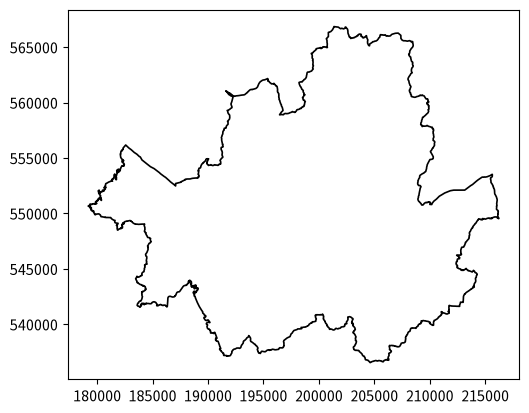

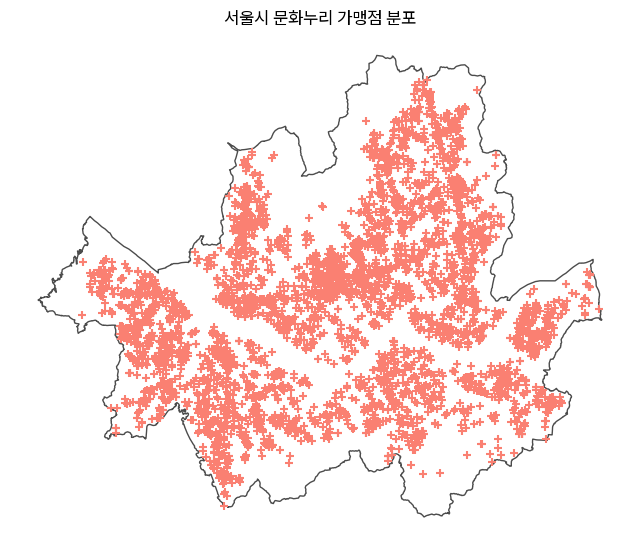

최종 가맹점 개수: 4702


In [28]:
# 행정동을 외곽경계로
seoul_bound = bound.dissolve()
display(seoul_bound)
print(seoul_bound.crs)
seoul_bound.plot(facecolor = 'None',
                 edgecolor = 'black',
                 linewidth = 1.2)

# crs 변경
seoul_bound = seoul_bound.to_crs(store_clean.crs)
print(f"변경 crs: {seoul_bound.crs}")

store_seoul = gpd.sjoin(store_clean,
                        seoul_bound[["geometry"]],
                        how =  'left',
                        predicate = 'within')

store_out = store_seoul[store_seoul["index_right"].isna()]

print("\n서울 경계 바깥 가맹점")
display(store_out)
print(f"경게 바깥 가맹점 개수: {len(store_out)}")

# 경게 바깥 가맹점 제거 및 불필요 칼럼 삭제
store_seoul = store_seoul[~(store_seoul["index_right"].isna())].copy()
store_seoul = store_seoul.drop(columns = 'index_right')

# 가맹점 위치 확인
fig, ax = plt.subplots(figsize=(8, 8))
seoul_bound.plot(ax=ax,
                 edgecolor = 'black',
                 alpha = 0.7,
                 facecolor = "None")
store_seoul.plot(ax=ax,
                 color = 'salmon',
                 marker = '+')
plt.title("서울시 문화누리 가맹점 분포")
ax.set_axis_off()
plt.savefig(IMAGE_PATH / "서울시_문화누리가맹점_위치_분포.png",
            bbox_inches = 'tight',
            pad_inches = 0.1,
            dpi = 240)
plt.show()

print(f"최종 가맹점 개수: {len(store_seoul)}")

In [29]:
store_seoul = store_seoul.copy()

store_seoul = store_seoul.sort_values(
    ["시군구", "가맹점명", "중분류", "소분류", "주소"]
).reset_index(drop=True)

store_seoul["가맹점_ID"] = [
    f"STORE_{i:05d}" for i in range(1, len(store_seoul) + 1)
]

store_seoul = store_seoul[
    [
        "가맹점_ID",
        "가맹점명",
        "시군구",
        "주소",
        "위도",
        "경도",
        "대분류",
        "중분류",
        "소분류",
        "전화결제",
        "장애인친화시설",
        "찾아가는문화서비스",
        "이용정보",
        "연관검색어",
        "이용분류_상세내용",
        "URL",
        "geometry"
    ]
]

bound_seoul = gpd.read_file(OUTPUT_PATH / "서울시_시군구_행정동_경계.gpkg")

store_seoul_hjd = gpd.sjoin(store_seoul,
                        bound_seoul[["행정동", "geometry"]],
                        how = 'left',
                        predicate = 'within')

print(store_seoul_hjd["행정동"].isna().sum())
print(len(store_seoul), len(store_seoul_hjd))

4702
4702 4702


C:\Users\박중현\AppData\Local\Temp\ipykernel_18180\1711763265.py:35: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: EPSG: 5179
Right CRS: EPSG:5186

  store_seoul_hjd = gpd.sjoin(store_seoul,


## 가맹점-행정동 결합 : PIP 방식
가맹점 제공 geometry Points와 행정동 경계 Polygon을 PIP 기반(within 메서드)로 공간 결합 

In [31]:
bound_seoul = gpd.read_file(OUTPUT_PATH / "서울시_시군구_행정동_경계.gpkg")

print(bound_seoul.crs)

bound_seoul = bound_seoul.to_crs(store_seoul.crs)

print(f"변경 후 crs: {bound_seoul.crs}")

store_seoul_hjd = gpd.sjoin(store_seoul,
                        bound_seoul[["행정동", "geometry"]],
                        how = 'left',
                        predicate = 'within').drop(columns = 'index_right',
                                                   errors = 'ignore')

print(store_seoul_hjd["행정동"].isna().sum())
print(len(store_seoul), len(store_seoul_hjd))
display(store_seoul_hjd.head(10))

# 칼럼 선택
store_seoul_final = store_seoul_hjd[
    [
        "가맹점_ID",
        "가맹점명",
        "시군구",
        "행정동",
        "주소",
        "위도",
        "경도",
        "대분류",
        "중분류",
        "소분류",
        "전화결제",
        "장애인친화시설",
        "찾아가는문화서비스",
        "이용정보",
        "연관검색어",
        "이용분류_상세내용",
        "URL",
        "geometry"
    ]
]

store_seoul_final.head()


EPSG:5186
변경 후 crs: EPSG: 5179
0
4702 4702


,가맹점_ID,가맹점명,시군구,주소,위도,경도,대분류,중분류,소분류,전화결제,장애인친화시설,찾아가는문화서비스,이용정보,연관검색어,이용분류_상세내용,URL,geometry,행정동
0,STORE_00001,(주) 드림네트웍스투어,강남구,서울 강남구 테헤란로 33길 18서울철강빌딩 5층 531호,37.502965,127.039322,관광,여행사,여행사,0,0,0,NaN,#관광#여행사#국내여행#국내여행사#(주) 드림네트웍스투어,NaN,NaN,POINT (959282.133 1944954.925),역삼1동
1,STORE_00002,(주) 보배렌트카,강남구,서울 강남구 광평로10길 50 2층 42호 보배렌트카,37.481063,127.083253,관광,교통수단,렌터카,0,0,0,NaN,#관광#교통수단#렌터카#렌트#(주) 보배렌트카,NaN,NaN,POINT (963154.316 1942506.922),일원본동
2,STORE_00003,(주) 에이치렌터카,강남구,서울 강남구 학동로 342 7층 723호,37.516751,127.040857,관광,교통수단,렌터카,0,0,0,NaN,#관광#교통수단#렌터카#렌트#(주) 에이치렌터카,NaN,NaN,POINT (959425.27 1946483.677),논현2동
3,STORE_00004,(주)굿네이버트래블,강남구,서울특별시 강남구 테헤란로 406 샹제리제센터 A동 14080호,37.504388,127.049989,관광,여행사,여행사,0,0,0,저희 굿네이버트래블은 그동안의 축적된 여행업의 경험으로 지방 또는 여행을 자주 접하...,#관광#여행#나드리#축제#페스타#문화#공연#스포츠,NaN,NaN,POINT (960225.742 1945108.28),대치4동
4,STORE_00005,(주)대명네트웍스,강남구,서울 강남구 테헤란로 222,37.501623,127.040756,관광,여행사,여행사,0,0,0,NaN,#관광#여행사#국내여행#국내여행사#(주)대명네트웍스,NaN,NaN,POINT (959408.154 1944805.419),역삼2동
5,STORE_00006,(주)롯데렌터카 논현점(롯데렌달(주)),강남구,서울특별시 강남구 학동로 216 성보빌딩 102호,37.514309,127.032795,관광,교통수단,렌터카,0,0,0,차량 렌탈,#관광#교통수단#렌트카#렌터카#롯데렌트카#롯데렌터카#차량대여#롯데렌터카 논현점#롯데...,NaN,NaN,POINT (958711.477 1946216.27),논현2동
6,STORE_00007,(주)민음북스,강남구,서울 강남구 신사동506번지 강남출판문화센터 5층,37.520742,127.019410,문화,도서,도서,0,0,0,NaN,#문화#도서#서점#서적#문고#책방#(주)민음북스,NaN,NaN,POINT (957532.238 1946935.976),신사동
7,STORE_00008,(주)서울오션아쿠아리움 (코엑스아쿠아리움),강남구,서울특별시 강남구 영동대로 513 코엑스몰 B1,37.566826,126.978652,관광,관광지,테마파크,0,0,0,수족관 입장권,#문화#공연#체험#수족관#관광#관광지#테마파크#여행#아쿠아리움#(주)서울오션아쿠아리움,NaN,https://www.coexaqua.com,POINT (953958.972 1952067.929),명동
8,STORE_00009,(주)석세스파트너,강남구,서울 강남구 테헤란로 406에이-120 지하1층,37.504382,127.049965,문화,도서,도서,0,0,0,NaN,#문화#도서#서점#서적#문고#책방#(주)석세스파트너,NaN,NaN,POINT (960223.591 1945107.536),대치4동
9,STORE_00010,(주)술술,강남구,서울 강남구 도곡동 339-2 서울시여성창업플라자 203호,37.490716,127.054928,문화,문화체험,문화체험,1,0,0,"전통 매듭을 활용한 악세사리, 인테리어 소품 만들기를 통해 전통문화를 체험해볼 수 ...",#문화체험#전통매듭#공예#소품#만들기,-프로그램 명 : 술술과 함께 매듭이 술술 (전통매듭 체험)<br>\n-유형 : 문...,NaN,POINT (960655.097 1943589.329),도곡2동


,가맹점_ID,가맹점명,시군구,행정동,주소,위도,경도,대분류,중분류,소분류,전화결제,장애인친화시설,찾아가는문화서비스,이용정보,연관검색어,이용분류_상세내용,URL,geometry
0,STORE_00001,(주) 드림네트웍스투어,강남구,역삼1동,서울 강남구 테헤란로 33길 18서울철강빌딩 5층 531호,37.502965,127.039322,관광,여행사,여행사,0,0,0,NaN,#관광#여행사#국내여행#국내여행사#(주) 드림네트웍스투어,NaN,NaN,POINT (959282.133 1944954.925)
1,STORE_00002,(주) 보배렌트카,강남구,일원본동,서울 강남구 광평로10길 50 2층 42호 보배렌트카,37.481063,127.083253,관광,교통수단,렌터카,0,0,0,NaN,#관광#교통수단#렌터카#렌트#(주) 보배렌트카,NaN,NaN,POINT (963154.316 1942506.922)
2,STORE_00003,(주) 에이치렌터카,강남구,논현2동,서울 강남구 학동로 342 7층 723호,37.516751,127.040857,관광,교통수단,렌터카,0,0,0,NaN,#관광#교통수단#렌터카#렌트#(주) 에이치렌터카,NaN,NaN,POINT (959425.27 1946483.677)
3,STORE_00004,(주)굿네이버트래블,강남구,대치4동,서울특별시 강남구 테헤란로 406 샹제리제센터 A동 14080호,37.504388,127.049989,관광,여행사,여행사,0,0,0,저희 굿네이버트래블은 그동안의 축적된 여행업의 경험으로 지방 또는 여행을 자주 접하...,#관광#여행#나드리#축제#페스타#문화#공연#스포츠,NaN,NaN,POINT (960225.742 1945108.28)
4,STORE_00005,(주)대명네트웍스,강남구,역삼2동,서울 강남구 테헤란로 222,37.501623,127.040756,관광,여행사,여행사,0,0,0,NaN,#관광#여행사#국내여행#국내여행사#(주)대명네트웍스,NaN,NaN,POINT (959408.154 1944805.419)


## 문화누리카드 가맹점 마스터 테이블(최종) 저장

In [32]:
# 간단 EDA
store_eda = store_seoul.copy()

store_type_mid = store_eda.groupby(by= "중분류").size()
store_type_small = store_eda.groupby(by= "소분류").size()
store_size_gu = store_eda.groupby(by = "시군구").size()

print(store_type_mid.sort_values(ascending=False))
print(store_type_small.sort_values(ascending=False))
print(store_size_gu.sort_values(ascending=False))

# 테이블 저장
store_seoul.to_file(OUTPUT_PATH / "서울시_문화누리카드_가맹점_2026.gpkg",
                    driver = "GPKG")


중분류
체육시설     1262
미술        876
도서        654
문화체험      621
체육용품      344
숙박        193
공연        187
음악        150
교통수단      125
영상        117
여행사       102
관광지        53
스포츠관람      18
dtype: int64
소분류
체육시설       1262
도서          654
문화체험        621
사진관         520
체육용품        344
공예          249
숙박          193
공연          187
음악          150
전시          107
여행사         102
렌터카          93
영화           91
TV           26
관광명소         20
테마파크         18
스포츠관람        18
시외/고속버스      13
철도            9
휴양림/캠핑장       8
여객선           6
국내항공          4
체험관광          3
동·식물원         2
온천            2
dtype: int64
시군구
종로구     412
강서구     309
노원구     245
송파구     244
강남구     230
마포구     221
중구      206
강동구     203
성북구     202
은평구     190
관악구     186
서초구     185
중랑구     182
영등포구    181
양천구     181
구로구     162
강북구     162
광진구     159
동대문구    147
도봉구     129
동작구     125
금천구     111
서대문구    111
성동구     111
용산구     108
dtype: int64


In [33]:
a = gpd.read_file(OUTPUT_PATH / "서울시_문화누리카드_가맹점_2026.gpkg")
a.head()

,가맹점_ID,가맹점명,시군구,주소,위도,경도,대분류,중분류,소분류,전화결제,장애인친화시설,찾아가는문화서비스,이용정보,연관검색어,이용분류_상세내용,URL,geometry
0,STORE_00001,(주) 드림네트웍스투어,강남구,서울 강남구 테헤란로 33길 18서울철강빌딩 5층 531호,37.502965,127.039322,관광,여행사,여행사,0,0,0,NaN,#관광#여행사#국내여행#국내여행사#(주) 드림네트웍스투어,NaN,NaN,POINT (959282.133 1944954.925)
1,STORE_00002,(주) 보배렌트카,강남구,서울 강남구 광평로10길 50 2층 42호 보배렌트카,37.481063,127.083253,관광,교통수단,렌터카,0,0,0,NaN,#관광#교통수단#렌터카#렌트#(주) 보배렌트카,NaN,NaN,POINT (963154.316 1942506.922)
2,STORE_00003,(주) 에이치렌터카,강남구,서울 강남구 학동로 342 7층 723호,37.516751,127.040857,관광,교통수단,렌터카,0,0,0,NaN,#관광#교통수단#렌터카#렌트#(주) 에이치렌터카,NaN,NaN,POINT (959425.27 1946483.677)
3,STORE_00004,(주)굿네이버트래블,강남구,서울특별시 강남구 테헤란로 406 샹제리제센터 A동 14080호,37.504388,127.049989,관광,여행사,여행사,0,0,0,저희 굿네이버트래블은 그동안의 축적된 여행업의 경험으로 지방 또는 여행을 자주 접하...,#관광#여행#나드리#축제#페스타#문화#공연#스포츠,NaN,NaN,POINT (960225.742 1945108.28)
4,STORE_00005,(주)대명네트웍스,강남구,서울 강남구 테헤란로 222,37.501623,127.040756,관광,여행사,여행사,0,0,0,NaN,#관광#여행사#국내여행#국내여행사#(주)대명네트웍스,NaN,NaN,POINT (959408.154 1944805.419)
